In [1]:
# ===== CELL 1 =====
# === [0] Setup + link prediction <-> image (LOCAL, no GPU) ===
# Link JSON<->image by replicating split (SEED=0). Verified alignment by pid + gt_boxes.
import os, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr
from collections import defaultdict, Counter

HERE = os.getcwd()                                   # run inside seminar/code/
DATA_DIR  = os.path.join(HERE, "data", "data_liver_multi_v3")
JSON_PATH = os.path.join(HERE, "eval", "eval_pred_gemma4_v3_0628_050605.json")  # change if needed
SEED = 0; COORD = 1000
rng_viz = np.random.default_rng(42)                  # separate seed for reproducible examples

def iou(b1, b2):
    if not b1 or not b2: return 0.0
    xa,ya=max(b1[0],b2[0]),max(b1[1],b2[1]); xb,yb=min(b1[2],b2[2]),min(b1[3],b2[3])
    inter=max(0,xb-xa)*max(0,yb-ya)
    a1=max(0,b1[2]-b1[0])*max(0,b1[3]-b1[1]); a2=max(0,b2[2]-b2[0])*max(0,b2[3]-b2[1])
    u=a1+a2-inter; return inter/u if u>0 else 0.0

def gt_overlap_ious(preds, gts):
    """Per-GT max IoU against any prediction. IoU > 0 means coarse overlap-detected."""
    return [max((iou(pred_box, gt_box) for pred_box in preds), default=0.0) for gt_box in gts]

def match_details(preds, gts):
    """Hungarian 1-1. Per-GT IoU keeps unmatched GT = 0, so missing boxes are penalized."""
    n_pred, n_gt = len(preds), len(gts)
    if not preds or not gts:
        return [], n_pred, n_gt, [0.0] * n_gt
    M=np.zeros((n_pred,n_gt))
    for i,pred_box in enumerate(preds):
        for j,gt_box in enumerate(gts): M[i,j]=iou(pred_box,gt_box)
    ri,ci=linear_sum_assignment(1-M)
    matches=[float(M[r,c]) for r,c in zip(ri,ci)]
    gt_ious=[0.0]*n_gt
    for r,c in zip(ri,ci): gt_ious[c]=float(M[r,c])
    return matches, n_pred, n_gt, gt_ious

def _annotate_metrics(r):
    mi, npd, ngt, gt_ious = match_details(r.get("pred_boxes", []), r.get("gt_boxes", []))
    r["matched_ious"] = mi
    r["gt_ious"] = gt_ious
    r["gt_overlap_ious"] = gt_overlap_ious(r.get("pred_boxes", []), r.get("gt_boxes", []))
    r["n_pred"] = npd
    r["n_gt"] = ngt
    r["best_iou"] = max((iou(pp,b) for b in r.get("gt_boxes", []) for pp in r.get("pred_boxes", [])), default=0.0)
    r["match_iou"] = float(np.mean(mi)) if mi else 0.0                  # matched pairs only
    d = max(npd, ngt)
    r["pen_iou"] = float(sum(mi) / d) if d else 0.0                    # penalize missing/extra boxes
    return r

def _area(b): return (b[2]-b[0])*(b[3]-b[1])
def _cnt_str(c): return " | ".join(f"{en}:{c.get(k,0)}" for k,en in [("nho","small"),("vua","medium"),("lon","large")])

def load_img(rel): return Image.open(os.path.join(DATA_DIR, rel)).convert("L")

def draw_box(ax, box, color, W, H, lw=1.6):
    x1,y1,x2,y2 = box[0]/COORD*W, box[1]/COORD*H, box[2]/COORD*W, box[3]/COORD*H
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=lw))

def zoom(ax, box, W, H, pad=75):
    cx,cy=(box[0]+box[2])/2*W/COORD,(box[1]+box[3])/2*H/COORD
    ax.set_xlim(cx-pad,cx+pad); ax.set_ylim(cy+pad,cy-pad)   # reversed ylim because origin is upper-left

# --- replicate split exactly like the main notebook split cell ---
rows = [json.loads(l) for l in open(os.path.join(DATA_DIR,"data.jsonl"), encoding="utf-8")]
rng = np.random.default_rng(SEED)
pids = sorted({r["patient_id"] for r in rows}); rng.shuffle(pids)
n=len(pids); n_tr,n_ca=int(n*0.6),int(n*0.2)
tr=set(pids[:n_tr]); ca=set(pids[n_tr:n_tr+n_ca])
test_rows=[r for r in rows if r["patient_id"] not in tr and r["patient_id"] not in ca]

d=json.load(open(JSON_PATH, encoding="utf-8")); preds=d["test"]; cal=d["cal"]
assert len(test_rows)==len(preds), f"len mismatch {len(test_rows)} vs {len(preds)}"
for i,(r,pred) in enumerate(zip(test_rows,preds)):
    assert r["patient_id"]==pred["pid"] and r["gt_boxes"]==pred["gt_boxes"], f"MISALIGNED i={i} (split mismatch?)"
records=[{**{k:r[k] for k in ["image_path","gt_boxes","patient_id"]},
          "pred_boxes":pred["pred_boxes"], "is_pos":pred["is_pos"],
          "logprob":pred["logprob"], "spatial":pred["spatial"], "selfconf":pred["selfconf"]}
         for r,pred in zip(test_rows,preds)]
for r in records: _annotate_metrics(r)

# lesion size tertiles over all positive test lesions
all_areas=[_area(b) for r in records if r["is_pos"] for b in r["gt_boxes"]]
Q1,Q2=np.percentile(all_areas,[33,67])
def size_cat(area): return "nho" if area<Q1 else ("vua" if area<Q2 else "lon")
EN_SZ={"nho":"SMALL","vua":"MEDIUM","lon":"LARGE"}
print(f"Link OK: {len(records)} slices ({sum(r['is_pos'] for r in records)} positive) | "
      f"{len(all_areas)} lesions | size tertiles: q1={Q1/1e4:.2f}% q2={Q2/1e4:.2f}% image")

Link OK: 255 slices (120 positive) | 206 lesions | size tertiles: q1=0.08% q2=0.26% image


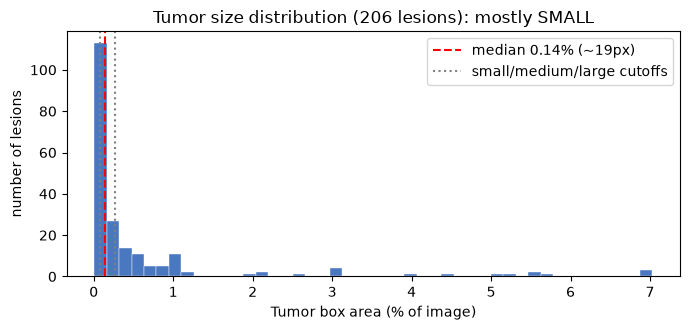

In [2]:
# ===== CELL 2 =====
# === [1] Phân bố cỡ u — DATA NGẬP U NHỎ (gốc của recall thấp) ===
ap=np.array(all_areas)/1e4
plt.figure(figsize=(7,3.4))
plt.hist(ap,bins=45,color="#4a78c0",edgecolor="white",linewidth=.3)
plt.axvline(np.median(ap),color="red",ls="--",lw=1.5,label=f"median {np.median(ap):.2f}% (~{np.sqrt(np.median(all_areas))*512/1000:.0f}px)")
plt.axvline(Q1/1e4,color="gray",ls=":"); plt.axvline(Q2/1e4,color="gray",ls=":",label="small/medium/large cutoffs")
plt.xlabel("Tumor box area (% of image)"); plt.ylabel("number of lesions")
plt.title(f"Tumor size distribution ({len(all_areas)} lesions): mostly SMALL"); plt.legend(); plt.tight_layout(); plt.show()

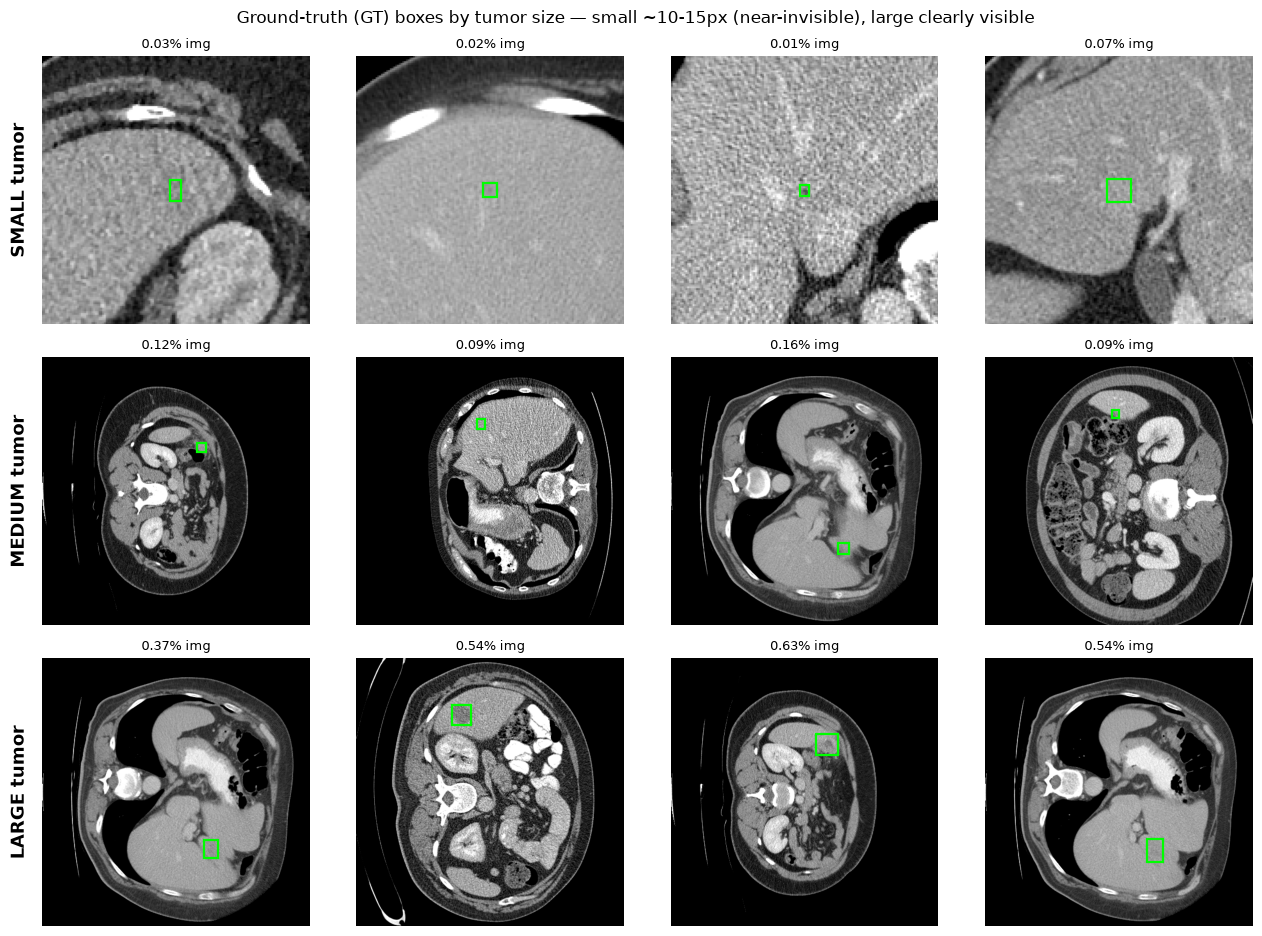

In [3]:
# ===== CELL 3 =====
# === [2] GT box theo 3 CỠ u (xanh=GT) — hàng NHỎ đã zoom ===
single=[r for r in records if r["is_pos"] and len(r["gt_boxes"])==1]
bysz=defaultdict(list)
for r in single:
    b=r["gt_boxes"][0]; bysz[size_cat((b[2]-b[0])*(b[3]-b[1]))].append(r)
fig,axes=plt.subplots(3,4,figsize=(13,9.5))
for ri,(sz,lbl) in enumerate([("nho","SMALL"),("vua","MEDIUM"),("lon","LARGE")]):
    pool=bysz[sz][:]; rng_viz.shuffle(pool); pick=pool[:4]
    for ci in range(4):
        ax=axes[ri,ci]; ax.axis("off")
        if ci>=len(pick): continue
        r=pick[ci]; img=load_img(r["image_path"]); W,H=img.size; box=r["gt_boxes"][0]
        ax.imshow(img,cmap="gray"); draw_box(ax,box,"lime",W,H)
        if sz=="nho": zoom(ax,box,W,H)
        a=(box[2]-box[0])*(box[3]-box[1]); ax.set_title(f"{a/1e4:.2f}% img",fontsize=9)
    axes[ri,0].text(-0.12,0.5,f"{lbl} tumor",transform=axes[ri,0].transAxes,
                    fontsize=13,fontweight="bold",rotation=90,va="center")
fig.suptitle("Ground-truth (GT) boxes by tumor size — small ~10-15px (near-invisible), large clearly visible",fontsize=12)
plt.tight_layout(); plt.show()

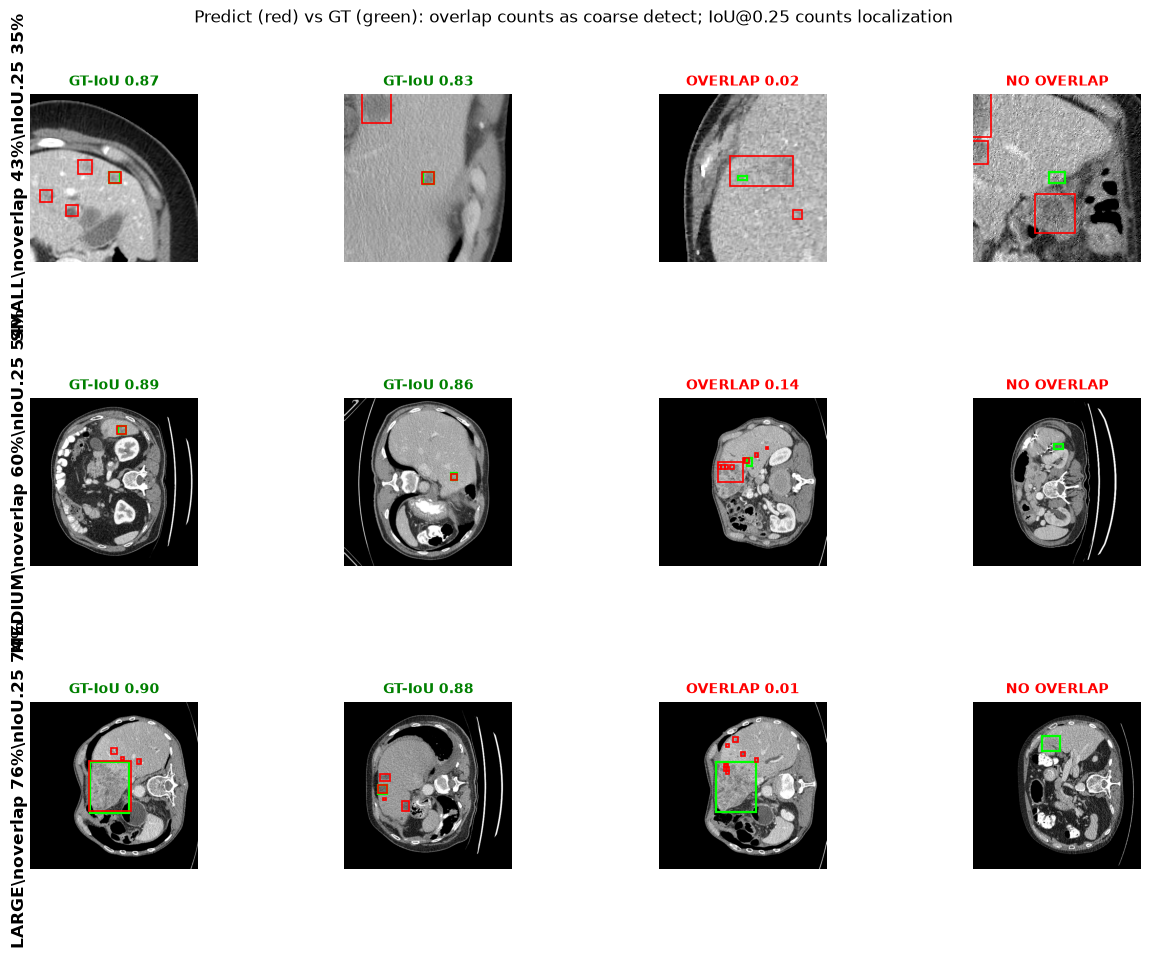

In [4]:
# ===== CELL 4 =====
# === [3] Model PREDICT (red) vs GT (green) by size ===
# Shows both coarse overlap-detect and stricter IoU@0.25 localization.
lesions=[]
for r in records:
    if not r["is_pos"]: continue
    for bi,b in enumerate(r["gt_boxes"]):
        giou = r["gt_ious"][bi] if bi < len(r["gt_ious"]) else 0.0
        oiou = r["gt_overlap_ious"][bi] if bi < len(r["gt_overlap_ious"]) else 0.0
        lesions.append({"r":r,"box":b,"iou":giou,"overlap_iou":oiou,"cat":size_cat(_area(b))})
fig,axes=plt.subplots(3,4,figsize=(13,9.5))
for ri,sz in enumerate(["nho","vua","lon"]):
    grp=[L for L in lesions if L["cat"]==sz]
    rec=np.mean([L["iou"]>=0.25 for L in grp]) if grp else 0
    det=np.mean([L["overlap_iou"]>0 for L in grp]) if grp else 0
    hit=sorted([L for L in grp if L["iou"]>=0.25],key=lambda x:-x["iou"])[:2]
    weak=[L for L in grp if L["overlap_iou"]>0 and L["iou"]<0.25]; rng_viz.shuffle(weak)
    miss=[L for L in grp if L["overlap_iou"]<=0]; rng_viz.shuffle(miss)
    pick=(hit+weak[:1]+miss[:1])[:4]
    for ci in range(4):
        ax=axes[ri,ci]; ax.axis("off")
        if ci>=len(pick): continue
        L=pick[ci]; r=L["r"]; img=load_img(r["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray"); draw_box(ax,L["box"],"lime",W,H)
        for pred_box in r["pred_boxes"]: draw_box(ax,pred_box,"red",W,H,lw=1.2)
        if sz=="nho": zoom(ax,L["box"],W,H,80)
        ok=L["iou"]>=0.25
        title = f"GT-IoU {L['iou']:.2f}" if ok else (f"OVERLAP {L['overlap_iou']:.2f}" if L["overlap_iou"]>0 else "NO OVERLAP")
        ax.set_title(title,fontsize=10,color=("green" if ok else "red"),fontweight="bold")
    axes[ri,0].text(-0.12,0.5,f"{EN_SZ[sz]}\\noverlap {det:.0%}\\nIoU.25 {rec:.0%}",transform=axes[ri,0].transAxes,
                    fontsize=12,fontweight="bold",rotation=90,va="center")
fig.suptitle("Predict (red) vs GT (green): overlap counts as coarse detect; IoU@0.25 counts localization",fontsize=12)
plt.tight_layout(); plt.show()

**Cell 5**

## Vi sao model bo sot? -- khong chi do u nho

Cell audit ben duoi tach tung GT lesion bi thieu theo 3 truc: kich thuoc, do tuong phan cuc bo, va tinh huong multi-box/undercount.

- Neu lesion nho hoac contrast thap: day nghieng ve **anh qua kho nhin / cat lat-windowing lam tin hieu yeu**.
- Neu lesion vua/lon, contrast khong thap ma van miss: day nghieng ve **model bo sot / decision detect chua tot / train chua hoc du**.

Do tuong phan o day chi la proxy tu PNG windowed CT quanh box, khong phai tumor mask that, nen dung de soi xu huong chu khong ket luan lam sang manh.


5 missed patients / 25 positive patients
  Mean largest-lesion area: missed 1.28% vs detected 1.32% image
  Missed patients by largest-lesion size: small:0 | medium:3 | large:2
  Detected patients by largest-lesion size: small:1 | medium:6 | large:13
  -> Missing is not only size; some large lesions have low contrast / are isointense.


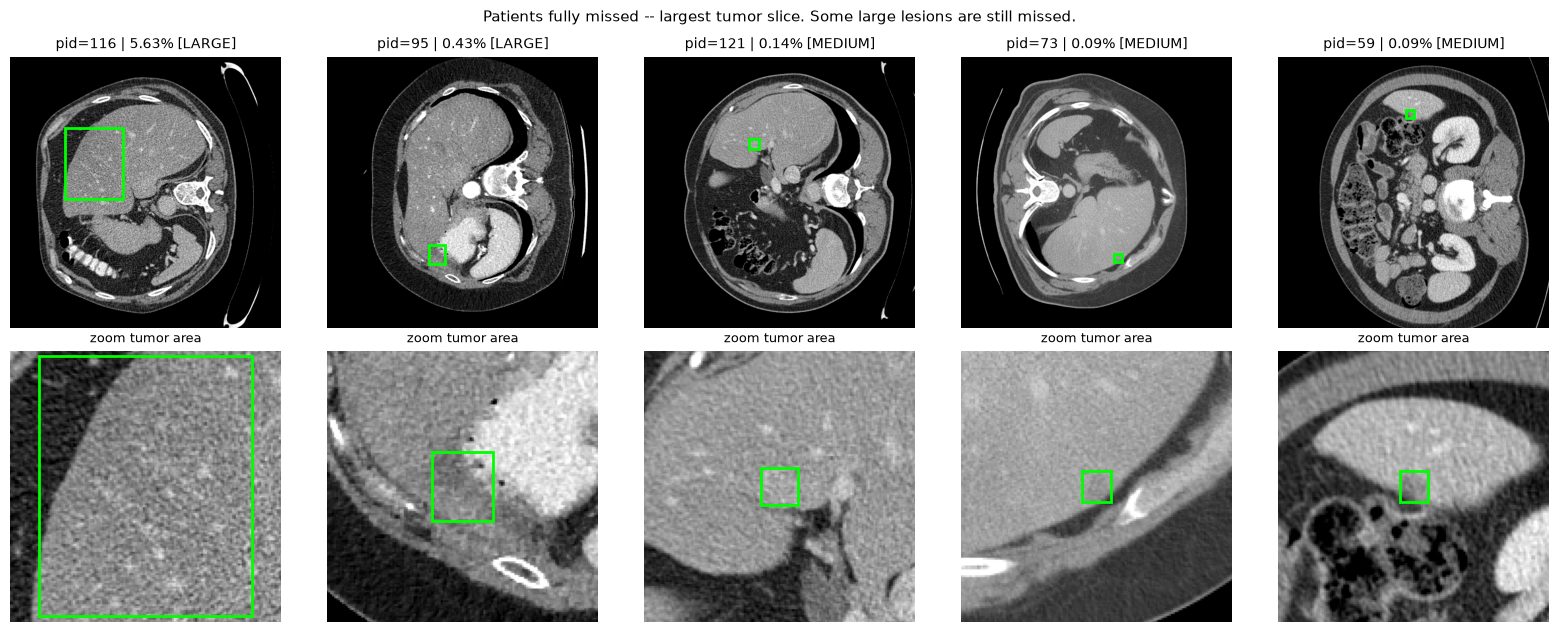

In [5]:
# ===== CELL 6 =====
# === [Missed patients] Patients where model draws 0 boxes on ALL positive slices ===
# Missing is not only about size: some large lesions are low-contrast / isointense.
bp = defaultdict(lambda: {"det": False, "sl": []})
for r in records:
    if r["is_pos"]:
        bp[r["patient_id"]]["sl"].append(r)
        if r["pred_boxes"]: bp[r["patient_id"]]["det"] = True
missed = [pid for pid, v in bp.items() if not v["det"]]
det    = [pid for pid, v in bp.items() if v["det"]]
def _maxarea(pid): return max(_area(b) for r in bp[pid]["sl"] for b in r["gt_boxes"])
miss_cat = Counter(size_cat(_maxarea(p)) for p in missed)
det_cat  = Counter(size_cat(_maxarea(p)) for p in det)
print(f"{len(missed)} missed patients / {len(bp)} positive patients")
if missed and det:
    print(f"  Mean largest-lesion area: missed {np.mean([_maxarea(p) for p in missed])/1e4:.2f}% "
          f"vs detected {np.mean([_maxarea(p) for p in det])/1e4:.2f}% image")
print(f"  Missed patients by largest-lesion size: {_cnt_str(miss_cat)}")
print(f"  Detected patients by largest-lesion size: {_cnt_str(det_cat)}")
print("  -> Missing is not only size; some large lesions have low contrast / are isointense.")

sel = sorted(missed, key=lambda p: -_maxarea(p))                  # largest first
fig, axs = plt.subplots(2, max(len(sel), 1), figsize=(3.2*max(len(sel), 1), 6.4))
axs = np.atleast_2d(axs)
for j, pid in enumerate(sel):
    r = max(bp[pid]["sl"], key=lambda r: max(_area(b) for b in r["gt_boxes"]))
    img = load_img(r["image_path"]); W, H = img.size
    b = max(r["gt_boxes"], key=_area)
    axs[0][j].imshow(img, cmap="gray"); draw_box(axs[0][j], b, "lime", W, H, 2)
    axs[0][j].set_title(f"pid={pid} | {_area(b)/1e4:.2f}% [{EN_SZ[size_cat(_area(b))]}]", fontsize=10); axs[0][j].axis("off")
    axs[1][j].imshow(img, cmap="gray"); draw_box(axs[1][j], b, "lime", W, H, 2); zoom(axs[1][j], b, W, H, pad=70)
    axs[1][j].set_title("zoom tumor area", fontsize=9); axs[1][j].axis("off")
plt.suptitle("Patients fully missed -- largest tumor slice. Some large lesions are still missed.", fontsize=11)
plt.tight_layout(); plt.show()

signal      Spearman(cal)
logprob            +0.863
spatial            -0.154
selfconf           +0.729


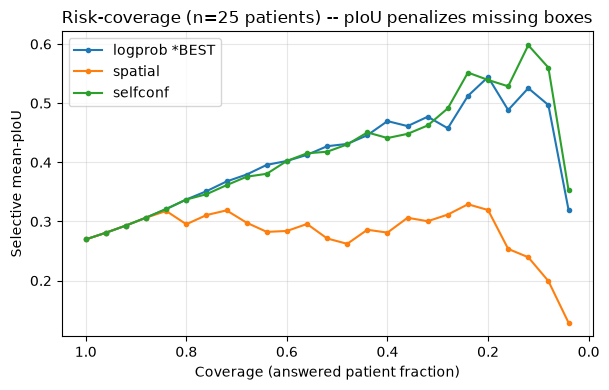


CAVEAT: n=25 patients is small -> proof-of-concept only, not a strong conclusion.


In [6]:
# ===== CELL 7 =====
# === [6] Risk-coverage + signal table (cal chooses / test reports) ===
# Quality target = pen_iou: sum matched IoU / max(n_pred,n_gt), so no-box and under-count are penalized.
SIG=["logprob","spatial","selfconf"]
def per_pat(rs):
    bp=defaultdict(list)
    for r in rs:
        if r["is_pos"]: bp[r["patient_id"]].append(r)
    pids=list(bp)
    pi=np.array([np.mean([x["pen_iou"] for x in bp[pid]]) for pid in pids])
    ps={}
    for k in SIG:
        vals=[]
        for pid in pids:
            xs=[x[k] for x in bp[pid] if x.get(k) is not None and np.isfinite(x.get(k))]
            vals.append(float(np.mean(xs)) if xs else np.nan)
        ps[k]=np.array(vals, dtype=float)
    return pi,ps
# cal: attach the same metrics as test
for c in cal:
    c["patient_id"]=c["pid"]
    _annotate_metrics(c)
Ti,Ts=per_pat(records); Ci,Cs=per_pat(cal)
print(f"{'signal':10}{'Spearman(cal)':>15}"); chosen={}; valid=[]
for k in SIG:
    mask=np.isfinite(Cs[k]) & np.isfinite(Ci)
    rho=spearmanr(Cs[k][mask],Ci[mask]).correlation if mask.sum()>1 and np.std(Cs[k][mask])>1e-9 else float('nan')
    chosen[k]=-1.0 if (not np.isnan(rho) and rho<0) else 1.0
    if not np.isnan(rho): valid.append((k,abs(rho)))
    print(f"{k:10}{rho:>+15.3f}")
BEST=max(valid,key=lambda x:x[1])[0] if valid else "logprob"
n=len(Ti); plt.figure(figsize=(6.2,4))
for k in SIG:
    s=chosen[k]*Ts[k]
    mask=np.isfinite(s)
    if mask.sum()==0: continue
    o=np.argsort(-s[mask]); ti=Ti[mask]
    plt.plot([(i+1)/len(ti) for i in range(len(ti))],
        [ti[o[:i+1]].mean() for i in range(len(ti))],marker="o",ms=3,label=k+(" *BEST" if k==BEST else ""))
plt.gca().invert_xaxis(); plt.xlabel("Coverage (answered patient fraction)"); plt.ylabel("Selective mean-pIoU")
plt.title(f"Risk-coverage (n={n} patients) -- pIoU penalizes missing boxes"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print()
print(f"CAVEAT: n={n} patients is small -> proof-of-concept only, not a strong conclusion.")

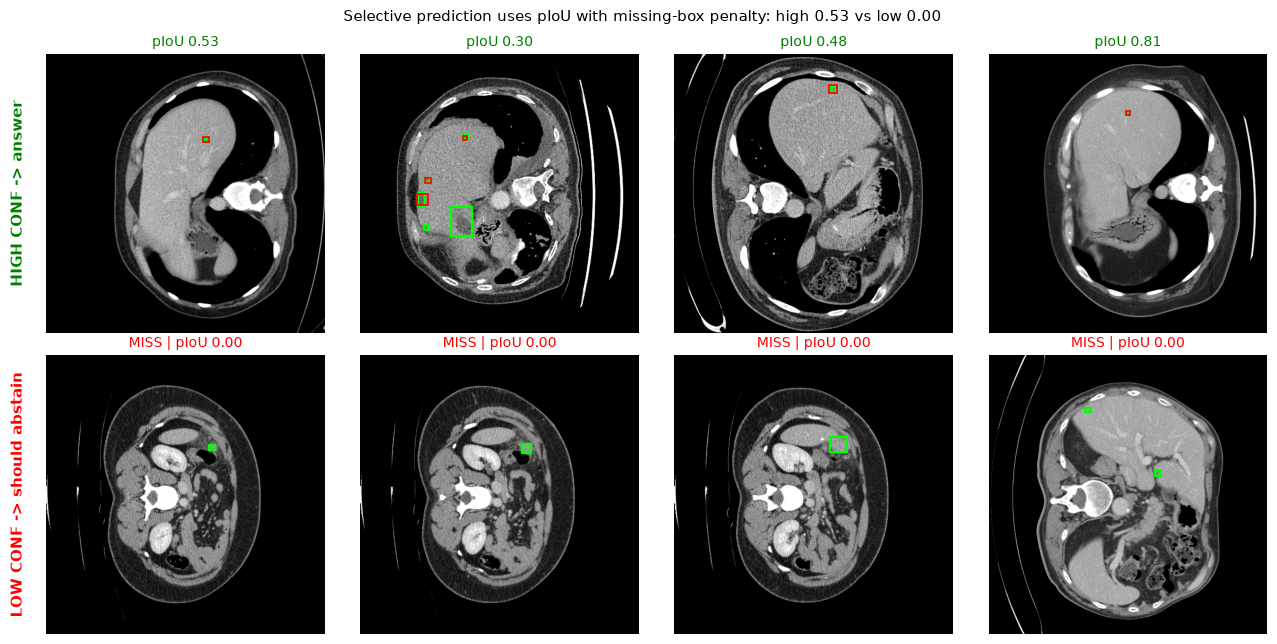

In [7]:
# ===== CELL 8 =====
# === [5] SELECTIVE PREDICTION (Direction-1) ===
# Do NOT filter out no-box positives: if model is confident but draws nothing, pIoU must be 0.
pos=[r for r in records if r["is_pos"]]
hi=sorted(pos,key=lambda r:-r["logprob"])[:4]      # high confidence
lo=sorted(pos,key=lambda r: r["logprob"])[:4]      # low confidence
fig,axes=plt.subplots(2,4,figsize=(13,6.6))
for row,(name,grp,col) in enumerate([("HIGH CONF -> answer",hi,"green"),("LOW CONF -> should abstain",lo,"red")]):
    for ci,r in enumerate(grp):
        ax=axes[row,ci]; img=load_img(r["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray")
        for b in r["gt_boxes"]: draw_box(ax,b,"lime",W,H)
        for pred_box in r["pred_boxes"]: draw_box(ax,pred_box,"red",W,H,lw=1.2)
        title = f"pIoU {r['pen_iou']:.2f}" if r["pred_boxes"] else "MISS | pIoU 0.00"
        ax.set_title(title,fontsize=10,color=("green" if r["pen_iou"]>=0.25 else "red")); ax.axis("off")
    axes[row,0].text(-0.13,0.5,name,transform=axes[row,0].transAxes,fontsize=11,
                     fontweight="bold",rotation=90,va="center",color=col)
hm=np.mean([r["pen_iou"] for r in hi]); lm=np.mean([r["pen_iou"] for r in lo])
fig.suptitle(f"Selective prediction uses pIoU with missing-box penalty: high {hm:.2f} vs low {lm:.2f}",fontsize=11)
plt.tight_layout(); plt.show()

**Cell 9**

## Model có quên tác vụ chat không?

Sau khi fine-tune chuyên phát hiện u, model **vẫn làm được các tác vụ tổng quát** (giải thích, tiếng Việt, JSON, thơ, toán) — bằng chứng **không quên thảm hoạ** nhờ LoRA giữ trọng số gốc.


In [8]:
# ===== CELL 10 =====
# === [No forgetting] Fine-tuned model still handles general tasks (chat/VN/JSON/poem/math) ===
import glob, json as _json
conv = _json.load(open(sorted(glob.glob(os.path.join(HERE,"eval","chat_test_*.json")))[-1], encoding="utf-8"))["conversations"][0]
def _find(kw):
    for t in conv["turns"]:
        if kw.lower() in t["hoi"].lower(): return t
show = [("Medical task (as trained)", conv["turns"][0]),
        ("Instruction-following",       _find("three reasons")),
        ("Vietnamese (language switch)", _find("Vietnamese for a patient")),
        ("Structured JSON output",       _find("JSON object")),
        ("Off-domain creativity (poem)", _find("poem")),
        ("Math",                         _find("17 times 23"))]
print("DID FINE-TUNING CAUSE FORGETTING?  -> one fine-tuned model, 6 task types\n")
for tag, t in show:
    if not t: continue
    q = "(detect prompt, same as training)" if t["hoi"].startswith("(") else t["hoi"]
    print(f"[{tag}]")
    print(f"  Q: {q[:88]}")
    print(f"  A: {t['dap'].strip()[:300]}\n")
print("=> Still does medical detection AND general chat / Vietnamese / JSON / poem / math")
print("   -> no catastrophic forgetting (LoRA keeps base weights).")


DID FINE-TUNING CAUSE FORGETTING?  -> one fine-tuned model, 6 task types

[Medical task (as trained)]
  Q: (detect prompt, same as training)
  A: No liver tumor is found.

[Instruction-following]
  Q: List exactly three reasons why this single CT slice is not enough for a final medical co
  A: 1. It is only a single cross-sectional slice, which may miss tumors located above or below this level.
2. A complete diagnosis requires viewing the entire abdominal scan to assess the liver's overall structure and surrounding organs.
3. Clinical context, patient history, and other diagnostic tests a

[Vietnamese (language switch)]
  Q: Now explain the same situation in Vietnamese for a patient, using simple words and at mo
  A: Bức ảnh này chỉ là một lát cắt nhỏ của bụng. Chúng tôi chưa thể đưa ra kết luận cuối cùng vì cần xem toàn bộ phim chụp. Bác sĩ cần xem thêm các lát cắt khác và biết thêm về tình trạng sức khỏe của bạn để đánh giá chính xác.

[Structured JSON output]
  Q: Return a compact J

**Cell 11**

## Nhận biết có/không u — TÁCH khỏi định vị

Tách 2 trục: **phát hiện** (model nói có u / không = vẽ box hay không) vs **định vị** (box khít cỡ nào, IoU). Model **nhận biết tốt** nhưng **định vị yếu hơn** — bảng dưới đo riêng phần "vẽ box hay không" so với nhãn, độc lập IoU.

**⚠️ Lưu ý:** chỉ ~25 bệnh nhân dương và **chỉ 2 bệnh nhân hoàn toàn không-u** → Spec/Prec 100% **rất yếu về thống kê** (n=2). "Specificity" ở đây = phân biệt lát-có-u vs lát-không-u **trong cùng bệnh nhân CÓ u**, **KHÔNG phải** specificity lâm sàng (phân biệt người bệnh vs người khỏe).


In [9]:
# ===== CELL 12 =====
# === [Nhận biết] Phân loại có/không u (VẼ BOX hay KHÔNG) — TÁCH khỏi định vị (IoU) ===
def _detect_report(rows, level):
    if level == "patient":
        bpx = defaultdict(lambda: [0, 0])
        for r in rows:
            bpx[r["patient_id"]][0] |= int(bool(r["gt_boxes"]))
            bpx[r["patient_id"]][1] |= int(len(r["pred_boxes"]) > 0)
        items = list(bpx.values())
    else:
        items = [[int(bool(r["gt_boxes"])), int(len(r["pred_boxes"]) > 0)] for r in rows]
    TP = sum(g and p for g, p in items); FP = sum((not g) and p for g, p in items)
    TN = sum((not g) and not p for g, p in items); FN = sum(g and not p for g, p in items); n = len(items)
    sens = TP/(TP+FN) if TP+FN else 0; spec = TN/(TN+FP) if TN+FP else 0
    prec = TP/(TP+FP) if TP+FP else 0; f1 = 2*prec*sens/(prec+sens) if prec+sens else 0
    print(f"  [{level:7}] n={n} TP={TP} FP={FP} TN={TN} FN={FN} | "
          f"Sens(catch tumor) {sens:.0%} | Spec {spec:.0%} | Prec {prec:.0%} | F1 {f1:.2f}")

print("== DETECTION: tumor vs no-tumor (draws a box or not, independent of IoU) ==")
_detect_report(records, "slice")
_detect_report(records, "patient")
print("  CAVEAT: only 2 fully tumor-free patients -> Spec/Prec 100% based on n=2 (very weak);")
print("          'Spec' = separating slices within tumor-bearing patients, NOT clinical specificity.")


== DETECTION: tumor vs no-tumor (draws a box or not, independent of IoU) ==
  [slice  ] n=255 TP=71 FP=2 TN=133 FN=49 | Sens(catch tumor) 59% | Spec 99% | Prec 97% | F1 0.74
  [patient] n=27 TP=20 FP=0 TN=2 FN=5 | Sens(catch tumor) 80% | Spec 100% | Prec 100% | F1 0.89
  CAVEAT: only 2 fully tumor-free patients -> Spec/Prec 100% based on n=2 (very weak);
          'Spec' = separating slices within tumor-bearing patients, NOT clinical specificity.


In [10]:
# ===== CELL 13 =====
# === [7] Summary table ===
pos=[r for r in records if r["is_pos"]]; neg=[r for r in records if not r["is_pos"]]
print("== LOCALIZATION ==")
ng=sum(r["n_gt"] for r in pos); npd=sum(r["n_pred"] for r in pos)
overlap_tp=sum(sum(v>0 for v in r.get("gt_overlap_ious", [])) for r in pos)
print(f"  overlap-detect(any IoU>0): recall {overlap_tp/ng:.0%} | TP {overlap_tp}/{ng} GT")
for th in [0.1,0.25,0.5,0.75]:
    tp=sum(sum(v>th for v in r["matched_ious"]) for r in pos)
    print(f"  @IoU>{th}: recall {tp/ng:.0%} | precision {(tp/npd if npd else 0):.0%} | TP {tp}/{ng} GT, {npd} pred")
no_box=sum(r["n_pred"]==0 for r in pos)
undercount_nonzero=sum(0<r["n_pred"]<r["n_gt"] for r in pos)
undercount_all=sum(r["n_pred"]<r["n_gt"] for r in pos)
miss_by_count=sum(max(0,r["n_gt"]-r["n_pred"]) for r in pos)
multi_under=sum(r["n_gt"]>1 and r["n_pred"]<r["n_gt"] for r in pos)
print(f"  Full-slice miss (0 box): {no_box}/{len(pos)} positive slices")
print(f"  Under-counted slices incl. 0-box: {undercount_all}/{len(pos)} | multi-box under-counted: {multi_under}")
print(f"  Has boxes but still under-counts: {undercount_nonzero} slices | count-missing = {miss_by_count} GT boxes")

bp=defaultdict(list)
bp_match=defaultdict(list)
for r in pos:
    bp[r["patient_id"]].append(r["pen_iou"])
    bp_match[r["patient_id"]].append(r["match_iou"])
pat=np.array([np.mean(v) for v in bp.values()])
pat_match=np.array([np.mean(bp_match[k]) for k in bp])
rngb=np.random.default_rng(0); idx=np.arange(len(pat))
ci=np.percentile([pat[rngb.choice(idx,len(idx),replace=True)].mean() for _ in range(2000)],[2.5,97.5])
print(f"  per-patient pIoU(missing/extra-box penalty) {pat.mean():.3f} | CI95 [{ci[0]:.3f}, {ci[1]:.3f}] | n={len(pat)} patients")
print(f"  reference only: matched-pair IoU (optimistic) {pat_match.mean():.3f}")

fp=sum(len(r['pred_boxes'])>0 for r in neg)
nbp=defaultdict(list)
for r in neg: nbp[r["patient_id"]].append(len(r["pred_boxes"])>0)
fp_pat=sum(any(v) for v in nbp.values())
print(f"== NEGATIVE SLICES == {len(neg)} slices | FP {fp} ({fp/len(neg):.1%}) | "
      f"per-patient {fp_pat}/{len(nbp)} ({fp_pat/len(nbp):.1%})")
print("   Note: these are tumor-free slices from patients with tumors, not clinical specificity on healthy patients.")

print()
print("== RECALL BY TUMOR SIZE ==")
les=[(_area(b),
      r["gt_ious"][bi] if bi < len(r["gt_ious"]) else 0.0,
      r["gt_overlap_ious"][bi] if bi < len(r["gt_overlap_ious"]) else 0.0)
     for r in pos for bi,b in enumerate(r["gt_boxes"])]
A=np.array([a for a,_,_ in les]); B=np.array([b for _,b,_ in les]); C=np.array([c for _,_,c in les])
for nm,lo,hi in [("SMALL",A.min()-1,Q1),("MEDIUM",Q1,Q2),("LARGE",Q2,A.max()+1)]:
    m=(A>=lo)&(A<hi)
    print(f"  {nm:5} n={int(m.sum()):3} overlap-detect={(C[m]>0).mean():.0%} "
          f"recall@.25={(B[m]>0.25).mean():.0%} recall@.5={(B[m]>0.5).mean():.0%}  GT-IoU={B[m].mean():.3f}")

== LOCALIZATION ==
  overlap-detect(any IoU>0): recall 60% | TP 123/206 GT
  @IoU>0.1: recall 56% | precision 71% | TP 116/206 GT, 163 pred
  @IoU>0.25: recall 54% | precision 69% | TP 112/206 GT, 163 pred
  @IoU>0.5: recall 38% | precision 48% | TP 79/206 GT, 163 pred
  @IoU>0.75: recall 12% | precision 15% | TP 24/206 GT, 163 pred
  Full-slice miss (0 box): 49/120 positive slices
  Under-counted slices incl. 0-box: 64/120 | multi-box under-counted: 19
  Has boxes but still under-counts: 15 slices | count-missing = 79 GT boxes
  per-patient pIoU(missing/extra-box penalty) 0.270 | CI95 [0.186, 0.359] | n=25 patients
  reference only: matched-pair IoU (optimistic) 0.324
== NEGATIVE SLICES == 135 slices | FP 2 (1.5%) | per-patient 2/27 (7.4%)
   Note: these are tumor-free slices from patients with tumors, not clinical specificity on healthy patients.

== RECALL BY TUMOR SIZE ==
  SMALL n= 68 overlap-detect=43% recall@.25=35% recall@.5=19%  GT-IoU=0.204
  MEDIUM n= 70 overlap-detect=60% r